In [10]:
# plot_names = ["Height of wave", "Depth averaged U"]
# for i in range(1, order+1):
#     plot_names.append(f"Alpha_{i}")

# # we need 1 extra plot for order 0 to order (included)
# # We need an extra 2 plots per row for height, and u_avg
# fig, axs = plt.subplots(order+1, order+2, 
#                         figsize=(30,20),layout="constrained")

# for row in range(order+1):
#     moment_i = data[data[:,0]==row]   

#     for col in range(order+2):
#         axs[row,col].plot(moment_i[:,1], moment_i[:,col+2])
        
#         if row == 0:
#             axs[0,col].set_title(plot_names[col])


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker

from pathlib import Path
from itertools import product

In [12]:
data_path = Path(os.getcwd()) / "Data-processing/Results/Omar"

data = pd.read_csv(data_path / "01-data_stacked.csv")
data_time = pd.read_csv(data_path / "02-time_stacked.csv")
errors = pd.read_csv(data_path / "03-errors.csv")   

In [13]:
# Common 
resolution_list = errors["Resolution"].unique()
plant_h_list = errors["Plant Height"].unique()   
error_types = ["L2 ", "LInf "]
quantities_list = ["Water Height","Average velocity","Velocity profile"]

color_blind_colors = ['#ffd700', '#0000ff', '#ea5f94', '#ffb14e', '#fa8775']
# color_blind_colors = ['#56B4E9', '#D55E00', '#009E73', '#CC79A7', '#E69F00']
color_map = {res: color_blind_colors[i % len(color_blind_colors)] for i, res in enumerate(resolution_list)}

marker_options = ["o", 's', "^"]
marker_map = {error: marker_options[i % len(marker_options)] for i, error in enumerate(error_types)}

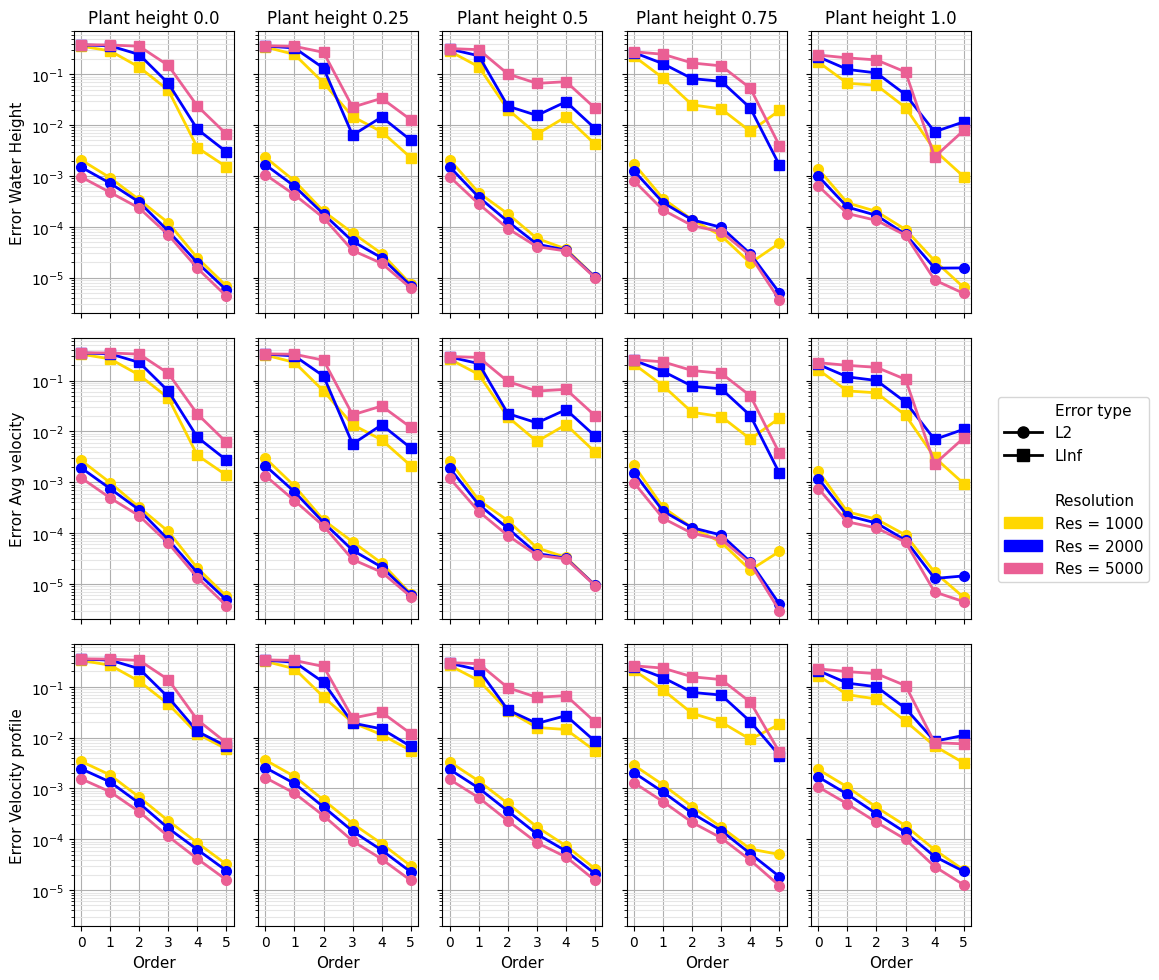

In [14]:
def create_legend_order_vs_error(fig):
    """ 
    Creates a single legend where it specifies:
        - What marker is associated to L2 norm and LInf
        - What color is linked to what resolution
    """
    marker_handles = []
    for error_type, marker in marker_map.items():
        handle = mlines.Line2D( [], [],
                                marker=marker,
                                markersize=8, color='black',
                                label=error_type.strip()
                            )
        marker_handles.append(handle)

    color_handles = []
    for res, color in color_map.items():
        handle = mpatches.Patch(color=color, label=f"Res = {int(res)}")
        color_handles.append(handle)

    # A blank line as a spacer
    blank = mlines.Line2D([], [], color='none', label='')  

    fig.legend(
        handles=[
            mlines.Line2D([], [], color='none', label='Error type'),   # header
            *marker_handles,
            blank,                                                       
            mlines.Line2D([], [], color='none', label='Resolution'),    # header
            *color_handles,
        ],
        loc='center left',    # places legend to the right of all subplots
        bbox_to_anchor = (1.0, 0.5),
        frameon=True,
        fontsize=11,
        handlelength=2.5,
    )

# for height in plant_h_list:

#     fig, axs = plt.subplots(1, 3, sharey=True)

#     for resolution in resolution_list:

#         mask = (errors["Plant Height"] == height) & (errors["Resolution"] == resolution)
        
#         for error_type in error_types:

#             axs[0].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Water Height"],
#                         linestyle='-',
#                         color=color_map[resolution],
#                         marker=marker_map[error_type])

#             axs[1].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Average Velocity"],
#                         linestyle='-',
#                         color=color_map[resolution],
#                         marker=marker_map[error_type])

#             axs[2].errorbar(errors.loc[mask,"Order"], errors.loc[mask, error_type+"U profile"],
#                             yerr=errors.loc[mask, "L2 std U profile"],
#                             color=color_map[resolution], 
#                             marker=marker_map[error_type])

#         axs[0].set_title("Water Height")
#         axs[1].set_title("Average velocity")
#         axs[2].set_title("Velocity profile")
#         axs[0].set_ylabel("Error")
#         axs[1].set_xlabel("Order of the polynomial")

#         for ax in axs.flatten():
#             ax.set_yscale("log")
#             ax.grid()
#             ax.grid(which="minor", color="0.9")
#             ax.set_ylim(2e-6,7e-1)
#             ax.set_xticks(range(0,6))

#         create_legend_order_vs_error(fig)
#         fig.suptitle(rf"Order vs error: Vegetation height = {height}", fontsize=11, fontweight='bold')
#         fig.tight_layout()
# plt.show()

############################    All in one plot     ############################
fig, axs = plt.subplots(3, 5, figsize=(10,10), sharex=True, sharey=True)

for i, height in enumerate(plant_h_list):

    for resolution in resolution_list:

        mask = (errors["Plant Height"] == height) & (errors["Resolution"] == resolution)
        
        for error_type in error_types:

            axs[0,i].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Water Height"],
                        linestyle='-',
                        color=color_map[resolution],
                        marker=marker_map[error_type])

            axs[1,i].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Average Velocity"],
                        linestyle='-',
                        color=color_map[resolution],
                        marker=marker_map[error_type])

            axs[2,i].errorbar(errors.loc[mask,"Order"], errors.loc[mask, error_type+"U profile"],
                            yerr=errors.loc[mask, "L2 std U profile"],
                            color=color_map[resolution], 
                            marker=marker_map[error_type])

for ax,h in zip(axs[0,:],plant_h_list): ax.set_title(f"Plant height {h}")
axs[0,0].set_ylabel("Error Water Height")
axs[1,0].set_ylabel("Error Avg velocity")
axs[2,0].set_ylabel("Error Velocity profile")
for ax in axs[-1,:]: ax.set_xlabel("Order")


for ax in axs.flatten():
    ax.set_yscale("log")
    ax.grid()
    ax.grid(which="minor", color="0.9")
    ax.set_ylim(2e-6,7e-1)
    ax.set_xticks(range(0,6))
create_legend_order_vs_error(fig)
fig.tight_layout()
plt.show()

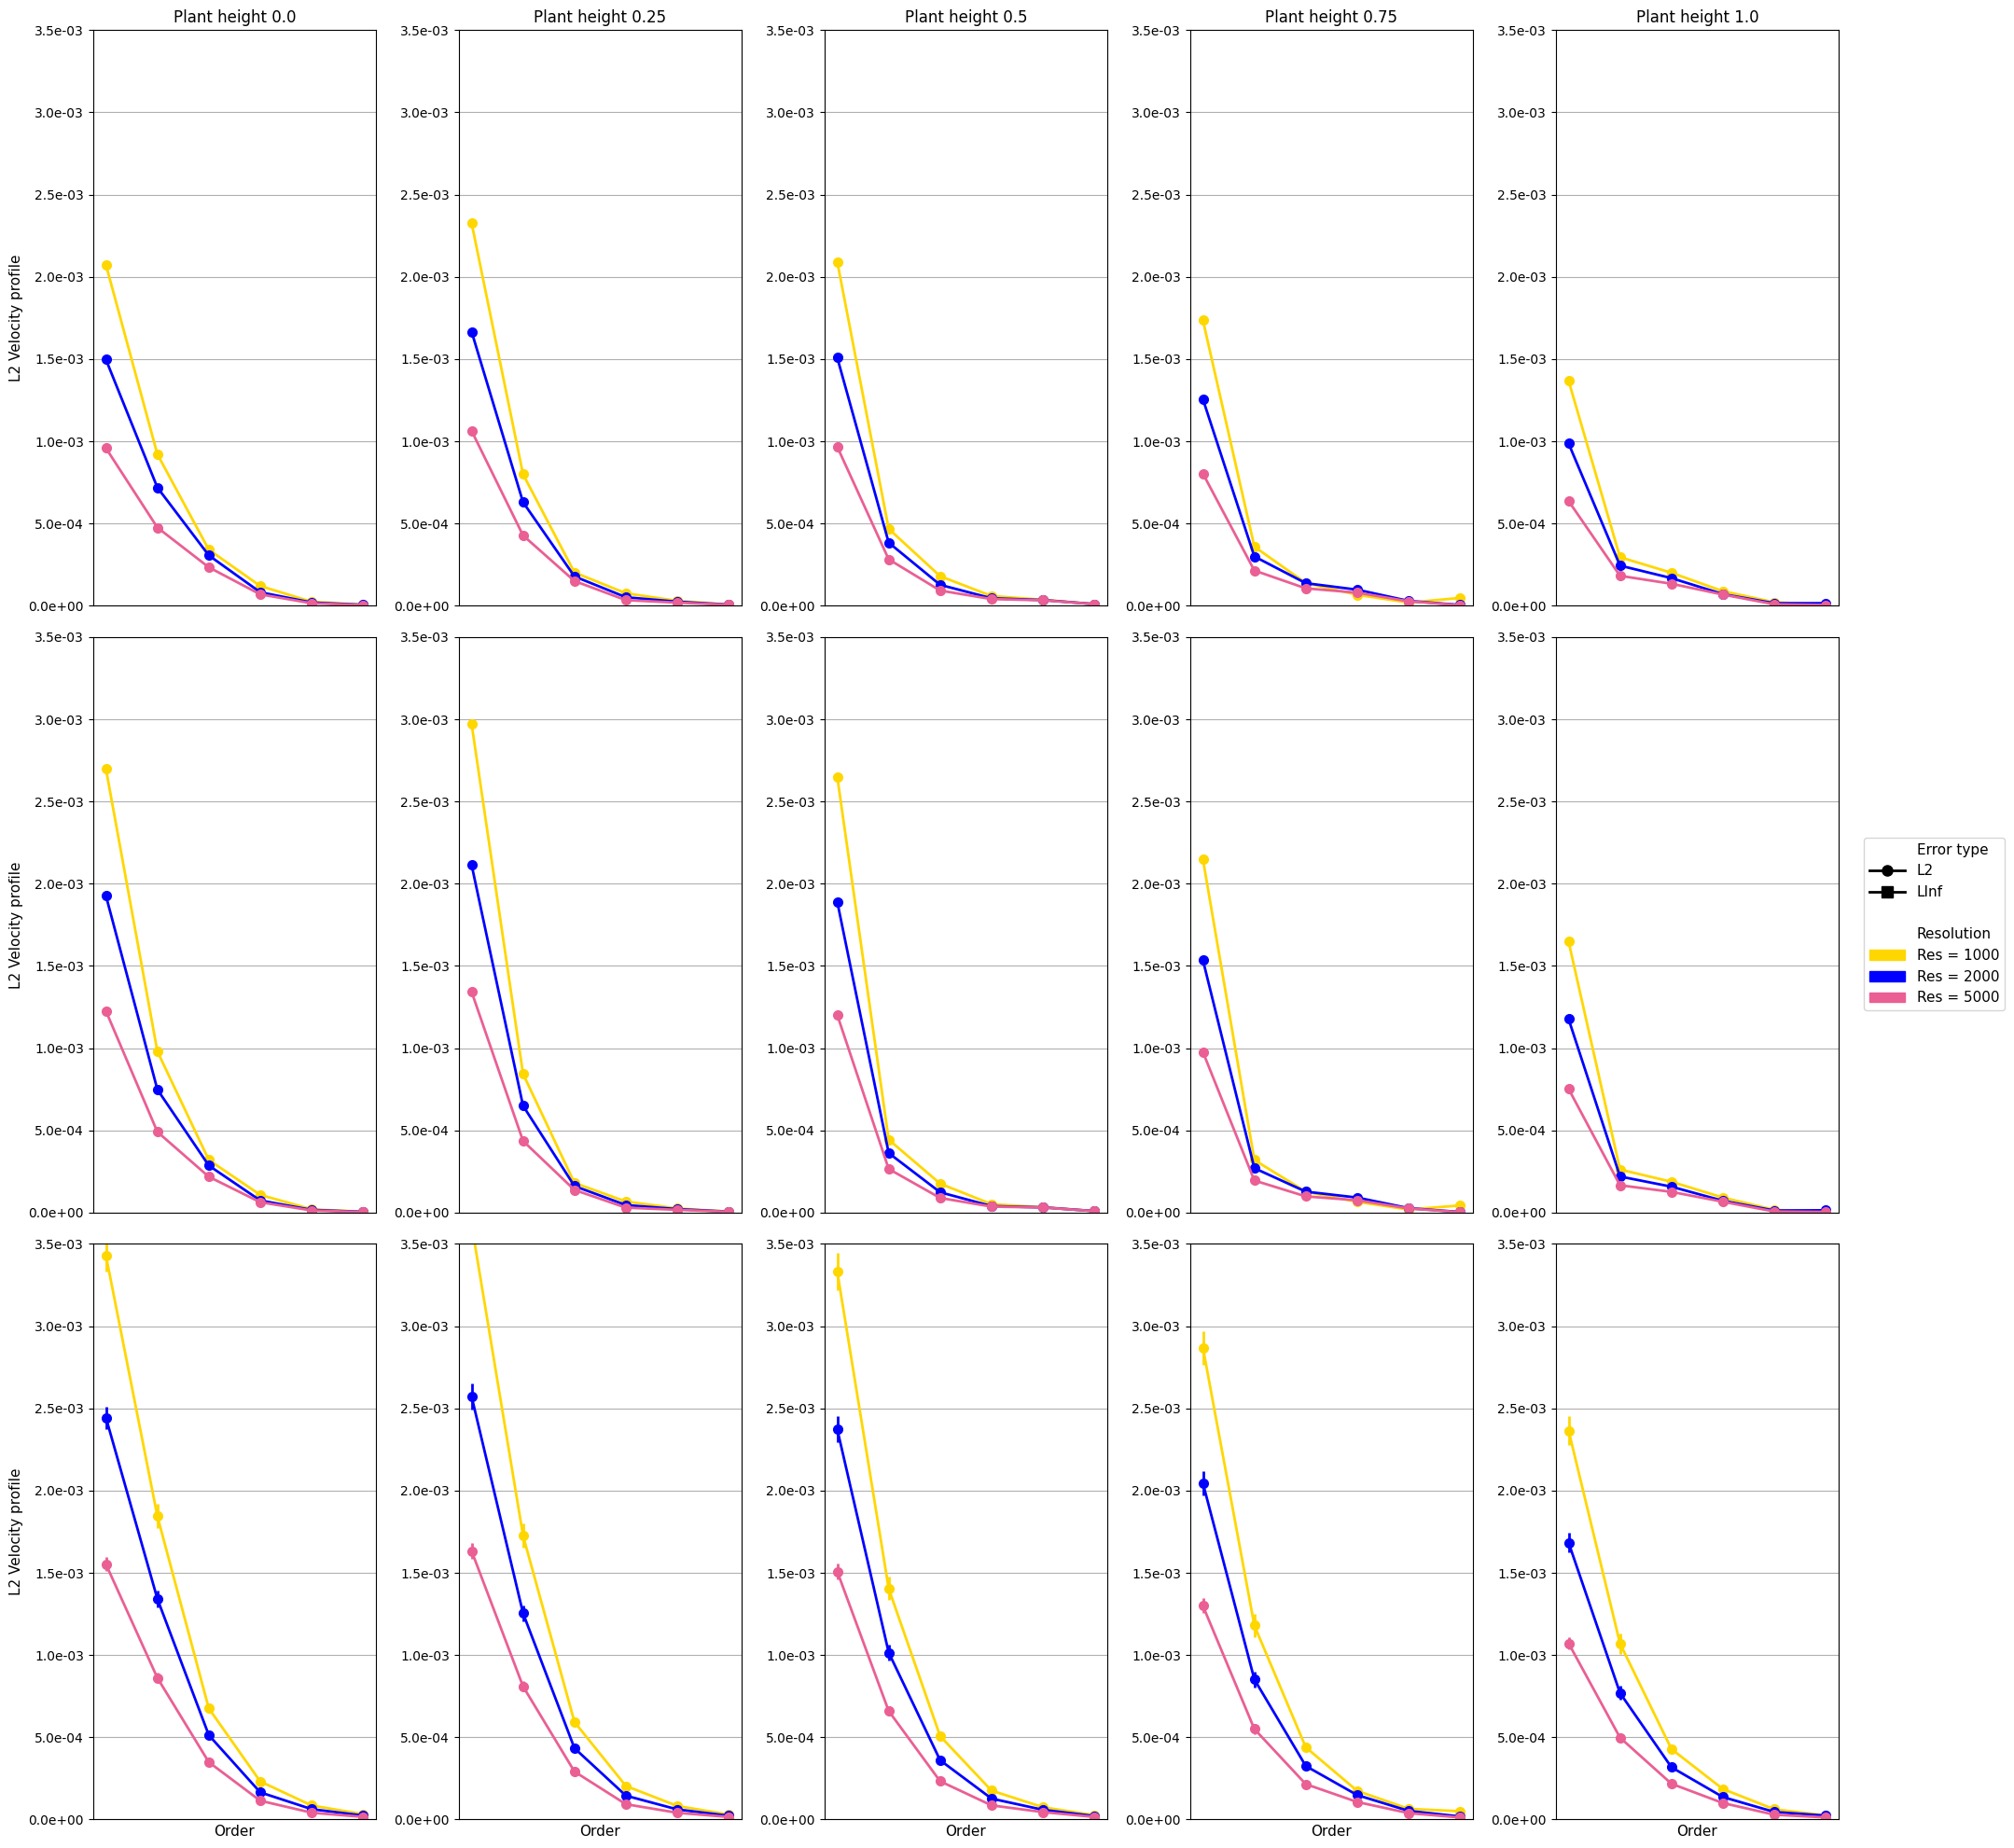

In [ ]:
resolution_list = errors["Resolution"].unique()
plant_h_list = errors["Plant Height"].unique()        

# Error vs resolution
fig, axs = plt.subplots(3, 5, figsize=(20,20), sharex=True)

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 12,
    'lines.linewidth': 2.0,
    'lines.markersize': 7,
})
error_types = ["L2 "]
for i, height in enumerate(plant_h_list):

    for resolution in resolution_list:

        mask = (errors["Plant Height"] == height) & (errors["Resolution"] == resolution)

        for j, error_type in enumerate(error_types):
            axs[0+3*j, i].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Water Height"],
                        linestyle='-',
                        marker=marker_map[error_type], 
                        color=color_map[resolution]
                    )

            axs[1+3*j, i].plot(errors.loc[mask,"Order"], errors.loc[mask, error_type+"Average Velocity"],
                        linestyle='-',
                        marker=marker_map[error_type], 
                        color=color_map[resolution]
                    )

            axs[2+3*j, i].errorbar(errors.loc[mask,"Order"], errors.loc[mask, error_type+"U profile"],
                        yerr=errors.loc[mask, "L2 std U profile"],
                        linestyle='-',
                        marker=marker_map[error_type], 
                        color=color_map[resolution]
                    )

for ax,h in zip(axs[0,:],plant_h_list): ax.set_title(f"Plant height {h}")
# for error_type in error_types:
#     for title in zip(error_types,quantity):
#TODO: I forgot what this was for hahaha

for ax, error_type, quantity in product(axs[:,0], error_types, quantities_list):
    ax.set_ylabel(error_type+quantity)
for ax in axs[-1,:]: ax.set_xlabel("Order")# of the polynomial")
for ax in axs[:3,:].flatten(): ax.set_ylim(0, 3.5e-3)
for ax in axs[3:,:].flatten(): ax.set_ylim(0, 4e-1)


for ax in axs.flatten():
    ax.grid()
    ax.grid(which="minor", color="0.9")
    ax.set_xticks(range(0,6))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: '{:.1e}'.format(x)))
create_legend_order_vs_error(fig)
fig.tight_layout()

In [16]:
errors

,Unnamed: 0,Resolution,Plant Height,Order,L2 Water Height,L2 Average Velocity,L2 U profile,L2 std U profile,LInf Water Height,LInf Average Velocity,LInf U profile,LInf std U profile
0,0,1000.0,0.0,0.0,0.002073,0.002698,0.003429,9.874153e-05,0.359206,0.330746,0.330531,0.002222
1,1,1000.0,0.0,1.0,0.000921,0.000981,0.001845,7.344934e-05,0.288673,0.266651,0.266237,0.001683
2,2,1000.0,0.0,2.0,0.000341,0.000320,0.000675,2.175822e-05,0.138369,0.128430,0.128232,0.000915
3,3,1000.0,0.0,3.0,0.000120,0.000108,0.000231,6.785998e-06,0.048675,0.045542,0.045747,0.000449
4,4,1000.0,0.0,4.0,0.000024,0.000020,0.000085,2.913163e-06,0.003607,0.003379,0.011857,0.000456
...,...,...,...,...,...,...,...,...,...,...,...,...
85,85,5000.0,1.0,1.0,0.000182,0.000166,0.000498,2.646392e-05,0.210224,0.198889,0.198767,0.000702
86,86,5000.0,1.0,2.0,0.000134,0.000126,0.000217,6.972281e-06,0.191759,0.181941,0.181744,0.000604
87,87,5000.0,1.0,3.0,0.000068,0.000066,0.000100,2.492315e-06,0.110990,0.105609,0.105487,0.000343
88,88,5000.0,1.0,4.0,0.000009,0.000007,0.000029,9.915510e-07,0.002374,0.002283,0.007960,0.000315


In [17]:
Average error

# fig, axs = plt.subplots(1,5, tight_layout=True)
# for i, height in enumerate(plant_h_list):

#     for resolution in resolution_list:

#         mask = errors["Resolu"]
#         axs[i] = plt.plot(errors["Order"])



SyntaxError: invalid syntax (2279482582.py, line 1)